In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving hotel_booking_cancellation_dataset(1).csv to hotel_booking_cancellation_dataset(1).csv


In [ ]:
import pandas as pd
import numpy as np
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "hotel": np.random.choice(["Resort Hotel", "City Hotel"], n),
    "lead_time": np.random.randint(0, 365, n),
    "adults": np.random.randint(1, 5, n),
    "children": np.random.randint(0, 3, n),
    "previous_cancellations": np.random.randint(0, 4, n),
    "previous_bookings_not_canceled": np.random.randint(0, 6, n),
    "booking_changes": np.random.randint(0, 5, n),
    "days_in_waiting_list": np.random.randint(0, 15, n),
    "adr": np.round(np.random.uniform(40, 300, n), 2),
    "required_car_parking_spaces": np.random.randint(0, 2, n),
    "total_of_special_requests": np.random.randint(0, 4, n),
    "deposit_type": np.random.choice(
        ["No Deposit", "Non Refund", "Refundable"], n
    ),
    "customer_type": np.random.choice(
        ["Transient", "Transient-Party", "Contract", "Group"], n
    ),
    "market_segment": np.random.choice(
        ["Online TA", "Offline TA/TO", "Direct", "Corporate", "Groups"], n
    )
})

score = (
    -1
    + 0.006 * df["lead_time"]
    + 0.9 * (df["previous_cancellations"] > 0)
    + 1.2 * (df["deposit_type"] == "Non Refund")
    - 0.25 * df["total_of_special_requests"]
)

probability = 1 / (1 + np.exp(-score))

df["is_canceled"] = (
    np.random.rand(n) < probability
).astype(int)
print("Dataset created successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()



Dataset created successfully!
Rows: 1000
Columns: 15


,hotel,lead_time,adults,children,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,deposit_type,customer_type,market_segment,is_canceled
0,Resort Hotel,144,2,1,1,4,1,6,143.29,1,3,No Deposit,Contract,Corporate,0
1,City Hotel,200,2,0,3,5,2,9,103.84,1,2,Refundable,Transient,Corporate,1
2,Resort Hotel,211,4,0,2,3,3,14,251.20,0,1,Refundable,Group,Direct,1
3,Resort Hotel,219,3,0,0,1,4,6,129.14,0,0,Refundable,Contract,Groups,1
4,Resort Hotel,239,2,1,2,3,1,12,68.99,1,1,Refundable,Transient,Groups,1


In [ ]:
print(df["is_canceled"].value_counts())

is_canceled
1    673
0    327
Name: count, dtype: int64


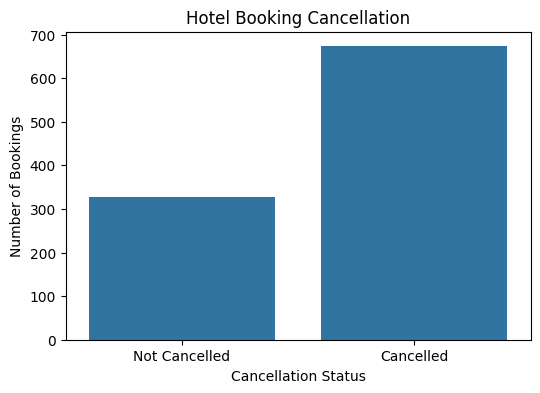

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x="is_canceled", data=df)

plt.title("Hotel Booking Cancellation")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")

plt.xticks([0, 1], ["Not Cancelled", "Cancelled"])

plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = [
    "hotel",
    "deposit_type",
    "customer_type",
    "market_segment"
]

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])

print("Categorical columns converted successfully!")

Categorical columns converted successfully!


In [ ]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (1000, 14)
Output shape: (1000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 14)
Testing data: (200, 14)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred = model.predict(X_test)

print("Prediction completed!")
print("First 20 predictions:")
print(y_pred[:20])

Prediction completed!
First 20 predictions:
[1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy, 4))
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Model Accuracy: 0.68
Accuracy Percentage: 68.0 %


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Cancelled", "Cancelled"]
))

Classification Report:

               precision    recall  f1-score   support

Not Cancelled       0.52      0.22      0.30        65
    Cancelled       0.71      0.90      0.79       135

     accuracy                           0.68       200
    macro avg       0.61      0.56      0.55       200
 weighted avg       0.64      0.68      0.63       200



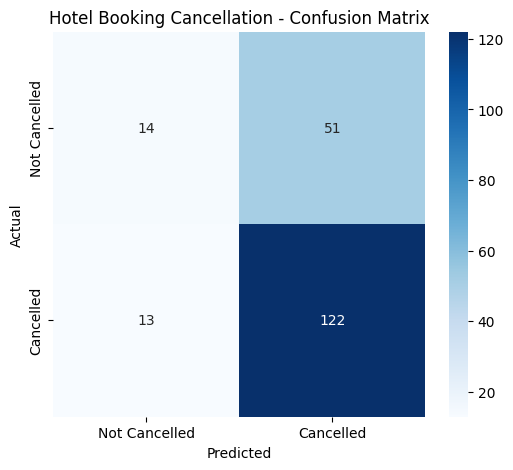

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Cancelled", "Cancelled"],
    yticklabels=["Not Cancelled", "Cancelled"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hotel Booking Cancellation - Confusion Matrix")

plt.show()

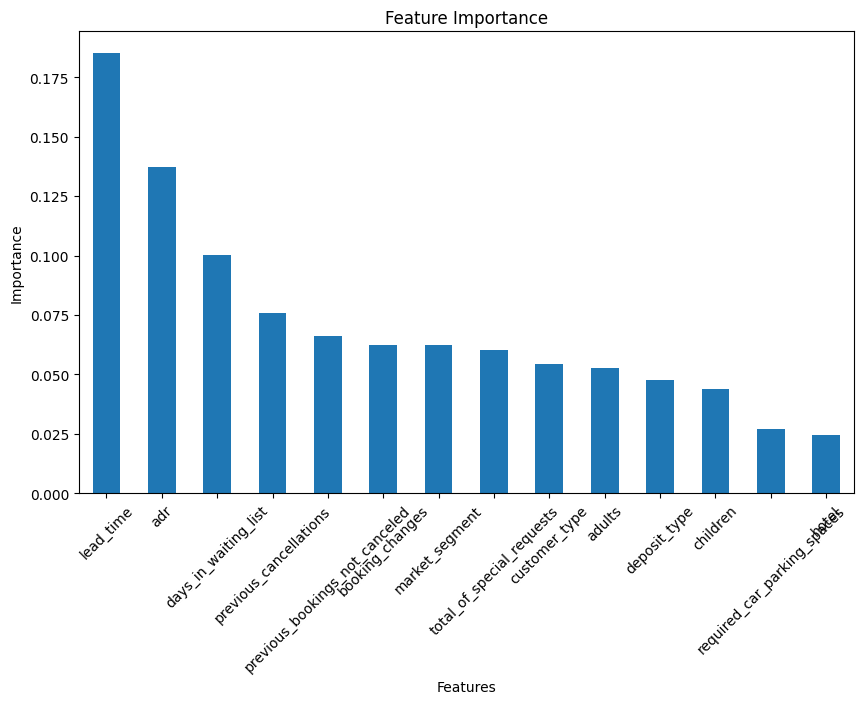

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.show()

In [ ]:
sample = X_test.iloc[[0]]

prediction = model.predict(sample)[0]

if prediction == 1:
    print("🔴 Booking Prediction: CANCELLED")
else:
    print("🟢 Booking Prediction: NOT CANCELLED")

🔴 Booking Prediction: CANCELLED


In [ ]:
probability = model.predict_proba(sample)[0]

print("Not Cancelled Probability:",
      round(probability[0] * 100, 2), "%")

print("Cancelled Probability:",
      round(probability[1] * 100, 2), "%")

Not Cancelled Probability: 22.0 %
Cancelled Probability: 78.0 %
